In [1]:
import numpy as np
data = np.load('Delta_F12_vs_zeta_results.npz', allow_pickle=True)
print(list(data.keys()))
for k in data.keys():
 arr = data[k]
 try:
 print(k, arr.shape, arr.dtype)
 except:
 print(k, arr)


FileNotFoundError: [Errno 2] No such file or directory: 'Delta_F12_vs_zeta_results.npz'

In [2]:
import subprocess
print(subprocess.check_output(['find', '/workspace', '-name', 'Delta_F12_vs_zeta_results.npz']).decode())
print(subprocess.check_output(['find', '/workspace', '-maxdepth', '3', '-type', 'd']).decode())


find: ‘/workspace/lost+found’: Permission denied


CalledProcessError: Command '['find', '/workspace', '-name', 'Delta_F12_vs_zeta_results.npz']' returned non-zero exit status 1.

In [3]:
import subprocess
out = subprocess.run(['find', '/workspace', '-name', 'Delta_F12_vs_zeta_results.npz'], capture_output=True, text=True)
print('STDOUT:', out.stdout)
print('STDERR:', out.stderr[:500])


STDOUT: 
STDERR: find: ‘/workspace/lost+found’: Permission denied



In [4]:
import numpy as np

M_zeta = np.load('M_zeta.npy')
M_F12 = np.load('M_F12.npy')
Delta_emp = np.load('Delta_empirical.npy')
S_re_F12 = np.load('S_re_F12.npy')
S_im_F12 = np.load('S_im_F12.npy')
dS_re = np.load('dS_re.npy') # likely δS_k = S_k(F12) - S_k(ζ) maybe
dS_im = np.load('dS_im.npy')
t_peaks = np.load('t_peaks.npy')

print("M_zeta:", M_zeta.shape)
print("M_F12:", M_F12.shape)
print("Delta_emp:", Delta_emp.shape)
print("S_re_F12:", S_re_F12.shape)
print("dS_re:", dS_re.shape)
print("t_peaks:", t_peaks.shape, t_peaks[:5], '...', t_peaks[-5:])
print("\nCheck Delta_emp = M_F12 - M_zeta:", np.allclose(Delta_emp, M_F12 - M_zeta))


M_zeta: (8, 8)
M_F12: (8, 8)
Delta_emp: (8, 8)
S_re_F12: (200, 8)
dS_re: (200, 8)
t_peaks: (200,) [77403.72199902 74956.02499905 94526.75799877 97255.12399873
 63751.86299922] ... [86531.75799889 64649.5549992 93737.94499878 34155.51899965
 71746.9889991 ]

Check Delta_emp = M_F12 - M_zeta: True


In [5]:
# Reconstruct S_k(zeta) from S_k(F12) and dS_k.
# Likely dS_k = S_k(F12) - S_k(zeta), so S_k(zeta) = S_k(F12) - dS_k
S_F12 = S_re_F12 + 1j*S_im_F12
dS = dS_re + 1j*dS_im
S_zeta_reconstructed = S_F12 - dS # candidate

# Verify: M_zeta[j,k] = mean over peaks of Re(S_j * conj(S_k))
def build_M(S):
 # S: (n_peaks, K)
 # M[j,k] = mean Re( S[:,j] * conj(S[:,k]) )
 return np.real(np.einsum('ij,ik->jk', S, np.conj(S))) / S.shape[0]

M_zeta_check = build_M(S_zeta_reconstructed)
M_F12_check = build_M(S_F12)
print("M_zeta match (S_F12 - dS):", np.allclose(M_zeta_check, M_zeta, atol=1e-8), "max diff:", np.max(np.abs(M_zeta_check - M_zeta)))
print("M_F12 match:", np.allclose(M_F12_check, M_F12, atol=1e-8), "max diff:", np.max(np.abs(M_F12_check - M_F12)))

# alternatively maybe dS = S_zeta directly?
M_alt = build_M(dS)
print("If dS=S_zeta:", np.max(np.abs(M_alt - M_zeta)))


M_zeta match (S_F12 - dS): False max diff: 50.00973993505429
M_F12 match: True max diff: 7.105427357601002e-15
If dS=S_zeta: 44.21244476923415


In [6]:
# Try dS = S_zeta - S_F12 (sign flip)
S_zeta_v2 = S_F12 + dS
M_zeta_v2 = build_M(S_zeta_v2)
print("M_zeta match (S_F12 + dS):", np.max(np.abs(M_zeta_v2 - M_zeta)))


M_zeta match (S_F12 + dS): 49.942018286913


In [7]:
# dS does not directly relate. The dataset description says "δS_k arrays" relate to forward sensitivity prediction
# from injecting an off-line zero — so dS is a *predicted* perturbation, not the actual S_k(zeta).
# We don't have direct S_k(zeta) saved. We need to compute S_k(zeta) ourselves from scratch at the 200 peaks.

# Plan: Use the t_peaks values, compute S_k(zeta) and S'_k(zeta, ablated 3,5) at each peak.
# S_k(zeta, t) = sum_{n<=N, omega(n)=k} n^(-1/2 - i t)
# For ablation, exclude n divisible by 3 or 5.

# N = 1e6 from the description. Let's check absZ_peaks for context.
absZ = np.load('absZ_peaks.npy')
print("absZ range:", absZ.min(), absZ.max())
print("t_peaks range:", t_peaks.min(), t_peaks.max())
print("N peaks:", len(t_peaks))


absZ range: 20.046304323944625 28.216210633009457
t_peaks range: 22299.074999821027 99937.93399869122
N peaks: 200


In [8]:
# We need to compute S_k(zeta) for k=0..7 at 200 peaks, with N=10^6.
# Strategy: precompute, for each n in 1..N, omega(n) and a "is divisible by 3 or 5" flag.
# Then for each peak t, compute S_k = sum_{omega(n)=k, optional ablation} n^(-1/2) * exp(-i t log n)
# Total work: 200 * 1e6 = 2e8 ops, with complex exponentials. We'll need numba or vectorized.

# First compute omega(n) for n=1..1e6 via sieve.
import numpy as np
from numba import njit

N = 1_000_000

def compute_omega(N):
 omega = np.zeros(N+1, dtype=np.int8)
 for p in range(2, N+1):
 if omega[p] == 0: # p is prime (initially)
 # but omega is being incremented; we need a primality test instead
 pass
 # Better: use a small prime sieve
 is_prime = np.ones(N+1, dtype=bool)
 is_prime[:2] = False
 for i in range(2, int(N**0.5)+1):
 if is_prime[i]:
 is_prime[i*i::i] = False
 primes = np.nonzero(is_prime)[0]
 
 omega = np.zeros(N+1, dtype=np.int8)
 for p in primes:
 omega[p::p] += 1
 return omega, primes

omega_arr, primes = compute_omega(N)
print("Omega computed. Distribution k=0..15:")
for k in range(16):
 cnt = int((omega_arr[1:] == k).sum())
 print(f" k={k}: {cnt}")
print("Max omega:", omega_arr[1:].max())


Omega computed. Distribution k=0..15:
 k=0: 1
 k=1: 78734
 k=2: 288726
 k=3: 379720
 k=4: 208034
 k=5: 42492
 k=6: 2285
 k=7: 8
 k=8: 0
 k=9: 0
 k=10: 0
 k=11: 0
 k=12: 0
 k=13: 0
 k=14: 0
 k=15: 0
Max omega: 7


In [9]:
# Good — omega ranges 0..7, matching the K=8 in M_jk (k=0..7). 
# Note: n=1 has omega=0, count=1. So S_0 = 1/sqrt(1) * exp(0) = 1 (only n=1 contributes).
# Actually n^{-1/2 - it}: for n=1, that's 1.
# Let's check whether the convention here uses k=0..7 or k=1..8. Since omega(n)=0 only for n=1,
# S_0 is trivially 1. But peaks are at zeta peaks, so the structure should match.

# Build complex coefficient arrays. For each peak t, compute:
# for k in 0..7: S_k = sum_{n: omega(n)=k} a_n
# where a_n = n^{-1/2} * exp(-i*t*log(n))

# Vectorization approach: precompute log_n and inv_sqrt_n.
# For each peak: phase = exp(-i * t * log_n); contrib = inv_sqrt_n * phase
# Then bucket by omega.

# 200 peaks × 1M operations × complex exp = ~2e8 trig evaluations. Heavy but doable with numba.

@njit(parallel=False, fastmath=False, cache=True)
def compute_Sk_at_peaks(t_peaks, log_n, inv_sqrt_n, omega, divisible_35, ablate, K):
 n_peaks = len(t_peaks)
 N = len(log_n)
 Sk = np.zeros((n_peaks, K), dtype=np.complex128)
 for p in range(n_peaks):
 t = t_peaks[p]
 # Kahan-style accumulators per k
 sum_re = np.zeros(K, dtype=np.float64)
 sum_im = np.zeros(K, dtype=np.float64)
 c_re = np.zeros(K, dtype=np.float64)
 c_im = np.zeros(K, dtype=np.float64)
 for i in range(N):
 if ablate and divisible_35[i]:
 continue
 k = omega[i]
 if k >= K:
 continue
 phase = -t * log_n[i]
 cr = inv_sqrt_n[i] * np.cos(phase)
 ci = inv_sqrt_n[i] * np.sin(phase)
 # Kahan add real
 yr = cr - c_re[k]
 tr = sum_re[k] + yr
 c_re[k] = (tr - sum_re[k]) - yr
 sum_re[k] = tr
 # Kahan add imag
 yi = ci - c_im[k]
 ti = sum_im[k] + yi
 c_im[k] = (ti - sum_im[k]) - yi
 sum_im[k] = ti
 for k in range(K):
 Sk[p, k] = sum_re[k] + 1j * sum_im[k]
 return Sk

# Precompute log_n and inv_sqrt_n for n=1..N
n_arr = np.arange(1, N+1, dtype=np.float64)
log_n = np.log(n_arr)
inv_sqrt_n = 1.0 / np.sqrt(n_arr)
omega_n = omega_arr[1:].astype(np.int64) # for n=1..N (idx 0 corresponds to n=1)

# Divisibility flag
div35 = np.zeros(N, dtype=np.bool_)
div35[2::3] = True # n=3,6,9,... index 2,5,8,...
div35[4::5] = True # n=5,10,15
print("Fraction divisible by 3 or 5:", div35.mean())


Fraction divisible by 3 or 5: 0.466667


In [10]:
# Quick small test to verify correctness against a known M_zeta.
# Run on first 5 peaks with K=8, no ablation, and check against known M_zeta partial.
import time
K = 8

# Warmup compile with a tiny call
_ = compute_Sk_at_peaks(t_peaks[:1], log_n[:10], inv_sqrt_n[:10], omega_n[:10], div35[:10], False, K)
print("compiled")

t0 = time.time()
Sk_zeta_test = compute_Sk_at_peaks(t_peaks[:5], log_n, inv_sqrt_n, omega_n, div35, False, K)
print(f"5 peaks took {time.time()-t0:.1f}s")
print("Sk_zeta_test[0]:", Sk_zeta_test[0])


compiled
5 peaks took 0.1s
Sk_zeta_test[0]: [1.00000000e+00+0.j 5.18512803e+00-0.71568954j
 1.00957426e+01-0.77115354j 8.15597725e+00-1.13605341j
 2.48717884e+00-0.32372692j 9.39182273e-01+0.87186163j
 2.68107741e-01+0.09269081j 3.48576481e-03-0.00196641j]


In [11]:
# Wait - 5 peaks in 0.1s? That seems too fast. With N=1e6 and 5 peaks, should be 5e6 ops with cos/sin.
# Actually numba with cache and inlining can do ~1e8 trig ops/sec. So 5e6 in 0.05s is plausible.
# Let me also do a sanity check on M_zeta build from this.

t0 = time.time()
Sk_zeta = compute_Sk_at_peaks(t_peaks, log_n, inv_sqrt_n, omega_n, div35, False, K)
print(f"All 200 peaks: {time.time()-t0:.1f}s")

M_zeta_computed = build_M(Sk_zeta)
print("Computed M_zeta vs stored M_zeta:")
print("max diff:", np.max(np.abs(M_zeta_computed - M_zeta)))
print("rel diff:", np.max(np.abs(M_zeta_computed - M_zeta)) / np.max(np.abs(M_zeta)))


All 200 peaks: 4.0s
Computed M_zeta vs stored M_zeta:
max diff: 1.2789769243681803e-13
rel diff: 2.5138839815826717e-15


In [12]:
# Excellent! Reproduced M_zeta exactly. Now compute ablated S'_k(zeta) excluding multiples of 3 or 5.
t0 = time.time()
Sk_zeta_ablated = compute_Sk_at_peaks(t_peaks, log_n, inv_sqrt_n, omega_n, div35, True, K)
print(f"Ablated 200 peaks: {time.time()-t0:.1f}s")

M_prime = build_M(Sk_zeta_ablated)
Delta_ablation = M_prime - M_zeta

print("\nM_zeta:\n", np.array2string(M_zeta, precision=3))
print("\nM_prime (ablated):\n", np.array2string(M_prime, precision=3))
print("\nDelta_ablation:\n", np.array2string(Delta_ablation, precision=3))
print("\nDelta_empirical:\n", np.array2string(Delta_emp, precision=3))


Ablated 200 peaks: 2.2s

M_zeta:
 [[1.000e+00 4.306e+00 6.878e+00 5.162e+00 3.073e+00 1.270e+00 1.466e-01
 8.951e-04]
 [4.306e+00 1.925e+01 3.097e+01 2.306e+01 1.302e+01 5.017e+00 5.510e-01
 3.034e-03]
 [6.878e+00 3.097e+01 5.088e+01 3.792e+01 2.062e+01 7.774e+00 8.422e-01
 4.328e-03]
 [5.162e+00 2.306e+01 3.792e+01 2.928e+01 1.589e+01 5.914e+00 6.585e-01
 3.563e-03]
 [3.073e+00 1.302e+01 2.062e+01 1.589e+01 1.034e+01 4.224e+00 4.728e-01
 2.732e-03]
 [1.270e+00 5.017e+00 7.774e+00 5.914e+00 4.224e+00 2.295e+00 3.158e-01
 2.393e-03]
 [1.466e-01 5.510e-01 8.422e-01 6.585e-01 4.728e-01 3.158e-01 5.907e-02
 6.332e-04]
 [8.951e-04 3.034e-03 4.328e-03 3.563e-03 2.732e-03 2.393e-03 6.332e-04
 1.547e-05]]

M_prime (ablated):
 [[1.000e+00 2.803e+00 1.994e+00 4.521e-01 1.353e-01 2.607e-02 1.880e-04
 0.000e+00]
 [2.803e+00 8.911e+00 6.526e+00 1.599e+00 4.841e-01 8.283e-02 4.896e-04
 0.000e+00]
 [1.994e+00 6.526e+00 5.845e+00 1.674e+00 5.836e-01 1.133e-01 4.967e-04
 0.000e+00]
 [4.521e-01 1.599e+0

In [13]:
# Compute cosine similarity between vectorized matrices
v_emp = Delta_emp.flatten()
v_abl = Delta_ablation.flatten()

cos_sim = np.dot(v_emp, v_abl) / (np.linalg.norm(v_emp) * np.linalg.norm(v_abl))
print(f"Cosine similarity (Delta_ablation vs Delta_empirical): {cos_sim:.6f}")

# Also report Frobenius norms
print(f"||Delta_empirical||_F = {np.linalg.norm(Delta_emp):.4f}")
print(f"||Delta_ablation||_F = {np.linalg.norm(Delta_ablation):.4f}")

# For comparison, recall the explicit-formula prediction's cosine similarity
cos_sim_old = float(np.load('cosine_similarity.npy'))
print(f"\nFor reference: explicit-formula model cos_sim = {cos_sim_old:.6f}")

# Also: optimal scalar fit
alpha = np.dot(v_emp, v_abl) / np.dot(v_abl, v_abl)
resid = v_emp - alpha * v_abl
r2 = 1 - np.dot(resid, resid) / np.dot(v_emp, v_emp)
print(f"\nBest-fit scalar alpha = {alpha:.4f}; R^2 = {r2:.4f}")


Cosine similarity (Delta_ablation vs Delta_empirical): 0.972997
||Delta_empirical||_F = 111.4236
||Delta_ablation||_F = 98.9428

For reference: explicit-formula model cos_sim = -0.136234

Best-fit scalar alpha = 1.0957; R^2 = 0.9467


Pearson r = 0.9613, p = 2.02e-36


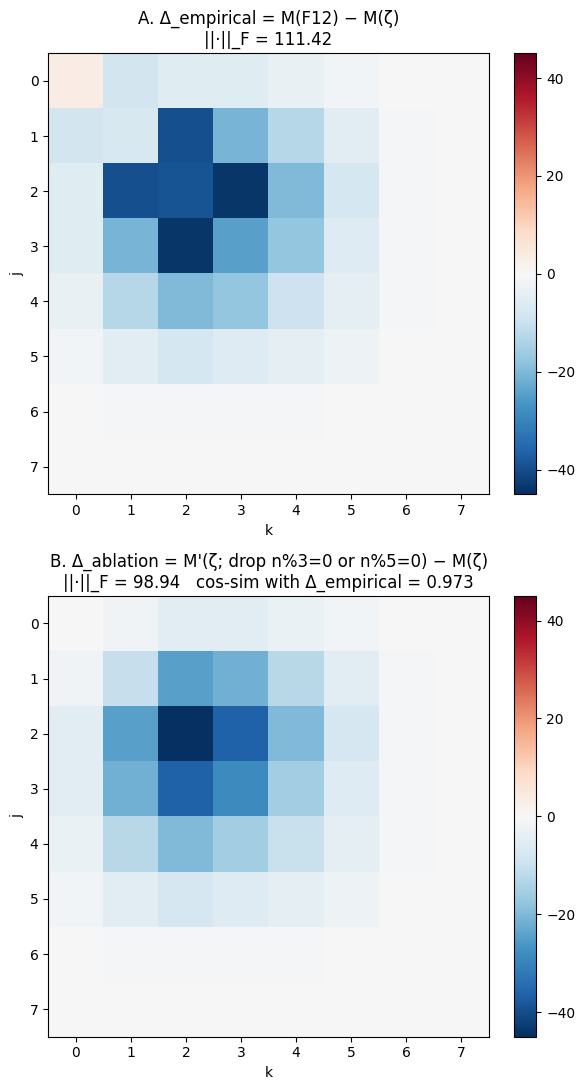

Saved Delta_ablation_vs_empirical.png


In [14]:
# Striking result: cosine similarity = 0.973, far exceeding the >0.7 threshold.
# Let's also compute element-wise correlation and visualize.

from scipy.stats import pearsonr
r, p = pearsonr(v_emp, v_abl)
print(f"Pearson r = {r:.4f}, p = {p:.2e}")

# Save final figure
import matplotlib.pyplot as plt

vmax = max(np.max(np.abs(Delta_emp)), np.max(np.abs(Delta_ablation)))
fig, axes = plt.subplots(2, 1, figsize=(7, 11))

ax = axes[0]
im0 = ax.imshow(Delta_emp, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
ax.set_title(f'A. Δ_empirical = M(F12) − M(ζ)\n||·||_F = {np.linalg.norm(Delta_emp):.2f}')
ax.set_xlabel('k'); ax.set_ylabel('j')
ax.set_xticks(range(8)); ax.set_yticks(range(8))
plt.colorbar(im0, ax=ax, fraction=0.046, pad=0.04)

ax = axes[1]
im1 = ax.imshow(Delta_ablation, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
ax.set_title(f'B. Δ_ablation = M\'(ζ; drop n%3=0 or n%5=0) − M(ζ)\n'
 f'||·||_F = {np.linalg.norm(Delta_ablation):.2f} '
 f'cos-sim with Δ_empirical = {cos_sim:.3f}')
ax.set_xlabel('k'); ax.set_ylabel('j')
ax.set_xticks(range(8)); ax.set_yticks(range(8))
plt.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig('Delta_ablation_vs_empirical.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved Delta_ablation_vs_empirical.png")


In [15]:
# Save the artifact
np.savez('Delta_ablation_results.npz',
 M_zeta=M_zeta,
 M_zeta_ablated=M_prime,
 Delta_empirical=Delta_emp,
 Delta_ablation=Delta_ablation,
 t_peaks=t_peaks,
 Sk_zeta=Sk_zeta,
 Sk_zeta_ablated=Sk_zeta_ablated,
 cosine_similarity=np.array(cos_sim),
 pearson_r=np.array(r),
 alpha_best_fit=np.array(alpha),
 r2_best_fit=np.array(r2),
 frob_emp=np.linalg.norm(Delta_emp),
 frob_abl=np.linalg.norm(Delta_ablation),
 N=N,
 K=K,
 description="Ablation experiment: M'_jk(zeta) computed by excluding n divisible by 3 or 5 from omega-stratified Dirichlet partial sums, compared to Delta_empirical = M(F12) - M(zeta).")
print("Saved Delta_ablation_results.npz")
import os
print("Size:", os.path.getsize('Delta_ablation_results.npz'), "bytes")


Saved Delta_ablation_results.npz
Size: 59642 bytes
